<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAINGUYENDUYVU2026/blob/main/Logtic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

data = pd.read_csv('/content/logistics_dataset.csv')

X = data[['OrderSize (kg)', 'Distance (km)', 'Fragile (0=Không, 1=Có)']]
y = data['Priority (0=Thấp, 1=Trung bình, 2=Cao)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))

new_order = [[50, 100, 1]]
new_order_scaled = scaler.transform(new_order)
prediction = model.predict(new_order_scaled)
print(f"\n=> Mức độ ưu tiên dự đoán cho đơn hàng mới: {prediction[0]}")

Độ chính xác (Accuracy): 100.00%

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


=> Mức độ ưu tiên dự đoán cho đơn hàng mới: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:

!pip install gradio -q

import pandas as pd
import numpy as np
import gradio as gr
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('/content/logistics_dataset.csv')

X = data[['OrderSize (kg)', 'Distance (km)', 'Fragile (0=Không, 1=Có)']]
y = data['Priority (0=Thấp, 1=Trung bình, 2=Cao)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
model.fit(X_scaled, y)


def predict_priority(order_size, distance, fragile):
    fragile_val = 1 if fragile == "Hàng dễ vỡ" else 0

    new_order = [[order_size, distance, fragile_val]]
    new_order_scaled = scaler.transform(new_order)

    prediction = int(model.predict(new_order_scaled)[0])

    results = {
        0: ("🟢 Mức độ ưu tiên: THẤP (0)", "Đơn hàng này không yêu cầu xử lý gấp."),
        1: ("🟡 Mức độ ưu tiên: BÌNH THƯỜNG (1)", "Đơn hàng cần được xử lý theo quy trình tiêu chuẩn."),
        2: ("🔴 Mức độ ưu tiên: CAO (2)", "CẦN XỬ LÝ GẤP! Đơn hàng có độ ưu tiên cao.")
    }

    return results[prediction][0], results[prediction][1]

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 🚚 Hệ Thống Dự Đoán Thứ Tự Ưu Tiên Logistics
        Nhập thông tin đơn hàng bên dưới để phân tích mức độ ưu tiên.
        """
    )

    with gr.Row():
        with gr.Column():
            order_input = gr.Number(label="Khối lượng hàng (kg)", value=50)
            dist_input = gr.Number(label="Khoảng cách vận chuyển (km)", value=100)
            fragile_input = gr.Radio(["Hàng thông thường", "Hàng dễ vỡ"], label="Tính chất hàng hóa", value="Hàng thông thường")
            btn = gr.Button("📊 PHÂN TÍCH NGAY", variant="primary")

        with gr.Column():
            output_title = gr.Textbox(label="Kết quả dự đoán")
            output_desc = gr.Textbox(label="Ghi chú vận hành")

    btn.click(fn=predict_priority,
              inputs=[order_input, dist_input, fragile_input],
              outputs=[output_title, output_desc])

    gr.Markdown(" Ứng dụng AI vào vận tải hàng hóa*")

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/tmp/ipykernel_3588/1614162893.py:37: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77e912fbdf9f50edbd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


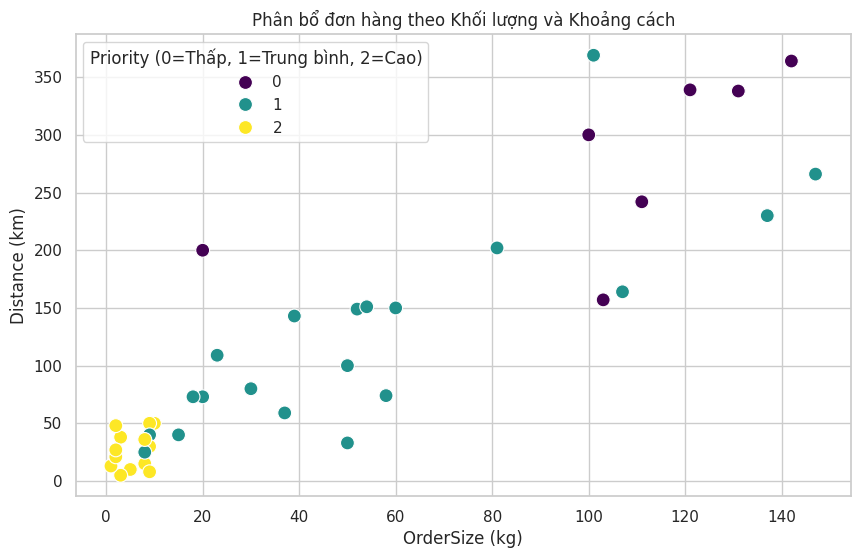

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho biểu đồ đẹp hơn
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Biểu đồ phân tán (Scatter Plot) - Mối quan hệ giữa Khối lượng, Khoảng cách và Ưu tiên
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='OrderSize (kg)', y='Distance (km)',
                hue='Priority (0=Thấp, 1=Trung bình, 2=Cao)',
                palette='viridis', s=100)
plt.title('Phân bổ đơn hàng theo Khối lượng và Khoảng cách')
plt.show()






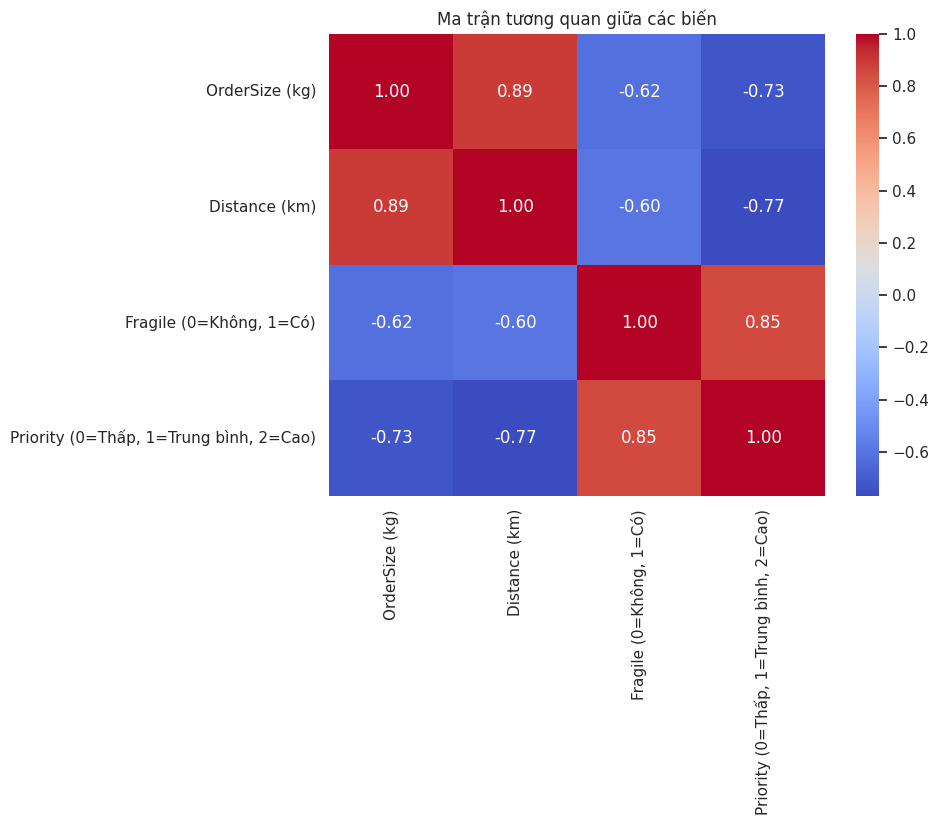

In [ ]:
# 3. Biểu đồ nhiệt (Heatmap) - Ma trận tương quan
# Giúp b biết yếu tố nào ảnh hưởng mạnh nhất đến Priority
plt.figure(figsize=(8, 6))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến')
plt.show()

/tmp/ipykernel_6102/2017307413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Priority (0=Thấp, 1=Trung bình, 2=Cao)', palette='Set2')


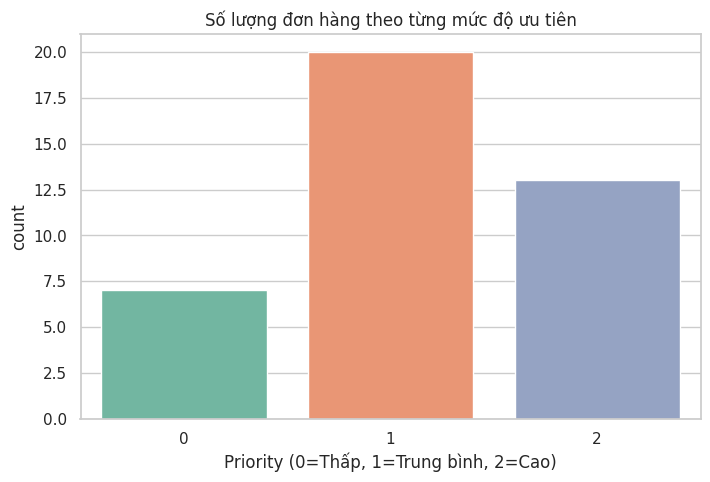

In [ ]:

# 2. Biểu đồ đếm (Count Plot) - Xem số lượng đơn hàng của từng mức ưu tiên
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Priority (0=Thấp, 1=Trung bình, 2=Cao)', palette='Set2')
plt.title('Số lượng đơn hàng theo từng mức độ ưu tiên')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


🎯 ĐỘ CHÍNH XÁC TỔNG THỂ (Accuracy): 87.50%

📋 BÁO CÁO CHI TIẾT (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         2

    accuracy                           0.88         8
   macro avg       0.89      0.92      0.89         8
weighted avg       0.92      0.88      0.88         8



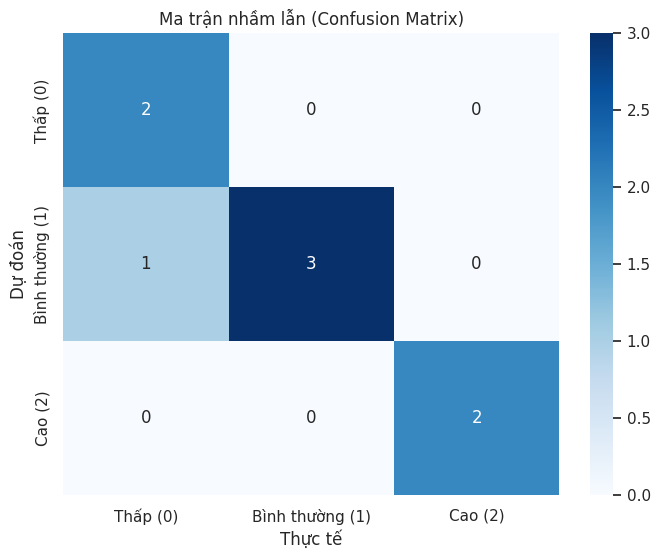

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Train lại mô hình trên tập Train
model.fit(X_train, y_train)

# 3. Dự đoán trên tập Test để kiểm tra độ "thông minh"
y_pred = model.predict(X_test)

# 4. Tính toán các chỉ số
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 ĐỘ CHÍNH XÁC TỔNG THỂ (Accuracy): {accuracy * 100:.2f}%")
print("\n📋 BÁO CÁO CHI TIẾT (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))

# 5. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
# Cái này cực quan trọng để biết model hay đoán nhầm mức nào với mức nào
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Thấp (0)', 'Bình thường (1)', 'Cao (2)'],
            yticklabels=['Thấp (0)', 'Bình thường (1)', 'Cao (2)'])
plt.xlabel('Thực tế')
plt.ylabel('Dự đoán')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()

In [ ]:
# 1. Tạo bảng dữ liệu sau khi chuẩn hóa
# X_scaled là mảng Numpy, mình đưa nó về DataFrame để có tên cột rõ ràng
X_scaled_df = pd.DataFrame(X_scaled, columns=['OrderSize (kg)', 'Distance (km)', 'Fragile (0=Không, 1=Có)'])

# 2. In ra 5 dòng đầu tiên để kiểm tra
print("--- BẢNG DỮ LIỆU SAU KHI CHUẨN HÓA (SCALED DATA) ---")
display(X_scaled_df.head())

# 3. In thêm các chỉ số thống kê để thấy sự thay đổi
print("\n--- THỐNG KÊ SAU CHUẨN HÓA (Trung bình ≈ 0, Độ lệch chuẩn ≈ 1) ---")
display(X_scaled_df.describe().round(2))

--- BẢNG DỮ LIỆU SAU KHI CHUẨN HÓA (SCALED DATA) ---


,OrderSize (kg),Distance (km),"Fragile (0=Không, 1=Có)"
0,0.056082,-0.188390,-0.693889
1,-0.905326,-1.014463,1.441153
2,-0.584857,0.729468,-0.693889
3,-0.798503,-0.647319,1.441153
4,-0.371210,-0.371962,-0.693889



--- THỐNG KÊ SAU CHUẨN HÓA (Trung bình ≈ 0, Độ lệch chuẩn ≈ 1) ---


,OrderSize (kg),Distance (km),"Fragile (0=Không, 1=Có)"
count,40.00,40.00,40.00
mean,0.00,-0.00,-0.00
std,1.01,1.01,1.01
min,-0.99,-1.06,-0.69
25%,-0.83,-0.78,-0.69
50%,-0.45,-0.43,-0.69
75%,0.82,0.48,1.44
max,2.13,2.28,1.44
